In [1]:
!pip install gensim
import pandas as pd
from wordcloud import WordCloud
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

**Dataset Loading**

In [2]:
train = pd.read_csv("/kaggle/input/datasets/mdezazulhaquemahi/440-datasets/Training_data_7.csv")
test = pd.read_csv("/kaggle/input/datasets/mdezazulhaquemahi/440-datasets/Test_data.csv")

print(train.head())
print(train.columns)
train = train.rename(columns={
    "News Headline": "text",
    "News Topic": "label"
})

test = test.rename(columns={
    "News Headline": "text",
    "News Topic": "label"
})

                                       News Headline              News Topic
0  <html> <body> News Headlines:\n <br> <b> IBM S...  Science and Technology
1  <html> <body> News Headlines:\n <br> <b> Seatt...                  Sports
2  <html> <body> News Headlines:\n <br> <b> Beach...                  Sports
3  <html> <body> News Headlines:\n <br> <b> Quatt...                Business
4  <html> <body> News Headlines:\n <br> <b> Repor...              World News
Index(['News Headline', 'News Topic'], dtype='object')


**optimum preprocessin**

In [3]:
import re
import numpy as np
import pandas as pd
import nltk
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [4]:
def preprocess_opt(text):
    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove special characters & numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    # Stopword removal
    words = [w for w in words if w not in stop_words]

    # Lemmatization ONLY (no stemming)
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

In [5]:
X3 = train['text']
y3 = train['label']

X3_clean = X3.apply(preprocess_opt)
le = LabelEncoder()
y3= le.fit_transform(y3)

X3_train, X3_val, y3_train, y3_val = train_test_split(
    X3_clean, y3, test_size=0.2, random_state=42, stratify=y3
)

**TF IDF**

In [6]:
#on preprocessing data

#on extreme preprocessing data

#on optimum preprocessing data
vec3= TfidfVectorizer(
    max_features=8000,        # reduce features (VERY IMPORTANT)
    ngram_range=(1,2),
    min_df=3,                 # remove rare noise words
    max_df=0.85
)
X3_train_tfidf = vec3.fit_transform(X3_train)
X3_val_tfidf   = vec3.transform(X3_val)

# Apply same preprocessing to test set
X3_test_clean = test['text'].apply(preprocess_opt)
X3_test_tfidf = vec3.transform(X3_test_clean)

X3_train_tfidf_nn = X3_train_tfidf.astype("float32").toarray()
X3_val_tfidf_nn   = X3_val_tfidf.astype("float32").toarray()
X3_test_tfidf_nn  = X3_test_tfidf.astype("float32").toarray()

**Skip Gram**

In [7]:
def preprocess_rnn(text):
    text = str(text).lower()

    # Better HTML removal (recommended)
    from bs4 import BeautifulSoup
    text = BeautifulSoup(text, "html.parser").get_text()

    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    # ❗ DO NOT REMOVE STOPWORDS
    # words = [w for w in words if w not in stop_words]  ❌ REMOVE THIS

    # Optional: light lemmatization
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)
X3_raw = train['text']
y3 = train['label']
X3_clean_rnn = X3_raw.apply(preprocess_rnn)
le = LabelEncoder()
y3 = le.fit_transform(y3)

X3_train, X3_val, y3_train, y3_val = train_test_split(
    X3_clean_rnn, y3,
    test_size=0.2,
    random_state=42,
    stratify=y3
)
# ==============================
# SKIP-GRAM (Word2Vec) COMPLETE PIPELINE
# ==============================

import numpy as np
from gensim.models import Word2Vec

# 🔹 Step 1: Tokenize (VERY IMPORTANT)
X3_train_tokens = [text.split() for text in X3_train]
X3_val_tokens   = [text.split() for text in X3_val]

# Test
X3_test_clean = test['text'].apply(preprocess_rnn)
X3_test_tokens = [text.split() for text in X3_test_clean]
# 🔹 Step 2: Train Skip-gram model
all_tokens = X3_train_tokens + X3_val_tokens
Skip = Word2Vec(
    vector_size=100,
    window=5,
    sg=1,           # Skip-gram
    min_count=2,    # ✅ Fix 2: was 1 — removes typos/noise
    workers=4,
    epochs=10       # ✅ Fix 3: move epochs here, cleaner API
)

Skip.build_vocab(all_tokens)
Skip.train(all_tokens, total_examples=len(all_tokens), epochs=10)

# 🔹 Step 3: Convert sentence → vector (AVERAGE WORD EMBEDDINGS)

def get_sentence_vector(tokens, model):
    vectors = []
    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

# 🔹 Step 4: Create NN input features

X3_train_w2v = np.array([get_sentence_vector(x, Skip) for x in X3_train_tokens])
X3_val_w2v   = np.array([get_sentence_vector(x, Skip) for x in X3_val_tokens])
X3_test_w2v  = np.array([get_sentence_vector(x, Skip) for x in X3_test_tokens])

# 🔹 Final check
print("Train shape:", X3_train_w2v.shape)
print("Val shape:", X3_val_w2v.shape)
print("Test shape:", X3_test_w2v.shape)

Train shape: (61008, 100)
Val shape: (15253, 100)
Test shape: (12000, 100)


In [8]:
y3_test = le.transform(test['label'])

**Logistic Regression**

In [9]:
#on optimum preprocessing data
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X3_train_tfidf, y3_train)

y_pred_lr = lr.predict(X3_val_tfidf)

print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y3_val, y_pred_lr))
print("F1-score (macro):", f1_score(y3_val, y_pred_lr, average='macro'))
print("\nConfusion Matrix:\n", confusion_matrix(y3_val, y_pred_lr))
print("\nClassification Report:\n", classification_report(y3_val, y_pred_lr))

===== Logistic Regression =====
Accuracy: 0.9156887169737101
F1-score (macro): 0.9034393076175199

Confusion Matrix:
 [[4202  176   32  153]
 [ 238 1498   25  136]
 [  28    8 3352   64]
 [ 218   74  134 4915]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91      4563
           1       0.85      0.79      0.82      1897
           2       0.95      0.97      0.96      3452
           3       0.93      0.92      0.93      5341

    accuracy                           0.92     15253
   macro avg       0.91      0.90      0.90     15253
weighted avg       0.92      0.92      0.92     15253



In [10]:
# Final test predictions
y_pred_lr_test = lr.predict(X3_test_tfidf)

print("===== Logistic Regression — TEST SET =====")
print("Accuracy:", accuracy_score(y3_test, y_pred_lr_test))
print("F1-score (macro):", f1_score(y3_test, y_pred_lr_test, average='macro'))
print("\nConfusion Matrix:\n", confusion_matrix(y3_test, y_pred_lr_test))
print("\nClassification Report:\n", classification_report(y3_test, y_pred_lr_test))

===== Logistic Regression — TEST SET =====
Accuracy: 0.8983333333333333
F1-score (macro): 0.8976118846433423

Confusion Matrix:
 [[2734  115   27  124]
 [ 404 2364   51  181]
 [  26    7 2918   49]
 [ 121   38   77 2764]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      3000
           1       0.94      0.79      0.86      3000
           2       0.95      0.97      0.96      3000
           3       0.89      0.92      0.90      3000

    accuracy                           0.90     12000
   macro avg       0.90      0.90      0.90     12000
weighted avg       0.90      0.90      0.90     12000



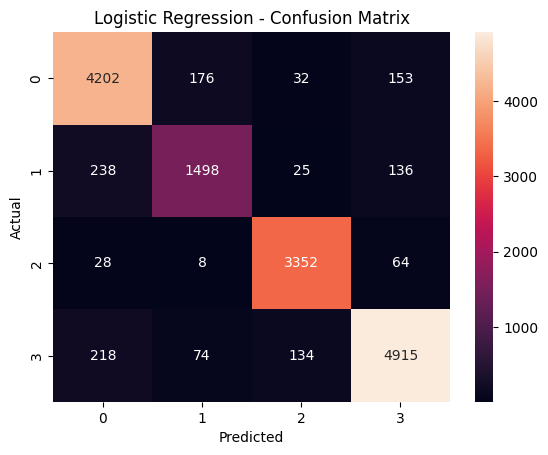

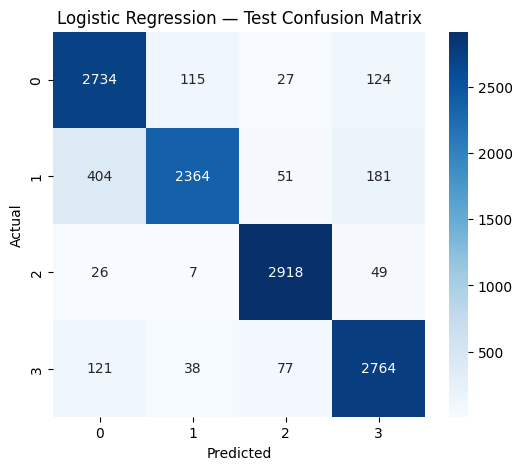

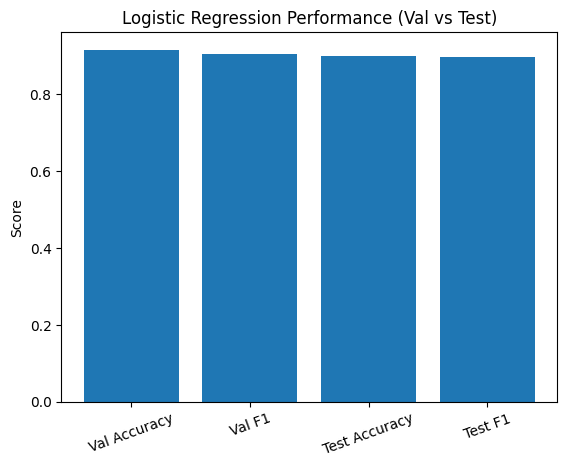

In [11]:
# Confusion Matrix - Logistic Regression

cm_lr = confusion_matrix(y3_val, y_pred_lr)

plt.figure()
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm = confusion_matrix(y3_test, y_pred_lr_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression — Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# Validation metrics
acc_lr_val = accuracy_score(y3_val, y_pred_lr)
f1_lr_val  = f1_score(y3_val, y_pred_lr, average='macro')

# Test metrics
y_pred_lr_test = lr.predict(X3_test_tfidf)
acc_lr_test = accuracy_score(y3_test, y_pred_lr_test)
f1_lr_test  = f1_score(y3_test, y_pred_lr_test, average='macro')

# Plot
import matplotlib.pyplot as plt

labels = ["Val Accuracy", "Val F1", "Test Accuracy", "Test F1"]
values = [acc_lr_val, f1_lr_val, acc_lr_test, f1_lr_test]

plt.figure()
plt.bar(labels, values)
plt.title("Logistic Regression Performance (Val vs Test)")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.show()

**Deep Neural Network**

In [12]:
# ==============================
# DEEP NEURAL NETWORK (TF-IDF)
# ==============================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(X3_train_tfidf_nn.shape[1],)),  # 128+ ✔
    Dropout(0.5),

    Dense(64, activation='relu'),
    Dropout(0.4),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(16, activation='relu'),

    Dense(4, activation='softmax')   # 4 classes
])

2026-04-23 18:04:03.276786: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776967443.464987      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776967443.521843      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776967443.936998      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776967443.937043      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776967443.937046      55 computation_placer.cc:177] computation placer alr

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']
)
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)
history = model.fit(
    X3_train_tfidf_nn,
    y3_train,
    validation_data=(X3_val_tfidf_nn, y3_val),
    epochs=100,              
    batch_size=128,
    callbacks=[es],
    verbose=1
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import numpy as np

# Predict
y_pred_prob = model.predict(X3_test_tfidf_nn)
y_pred_dnn = np.argmax(y_pred_prob, axis=1)

print("===== DNN (TF-IDF) =====")
print("Accuracy:", accuracy_score(y3_test, y_pred_dnn))
print("F1-score (macro):", f1_score(y3_test, y_pred_dnn, average='macro'))

print("\nConfusion Matrix:\n", confusion_matrix(y3_test, y_pred_dnn))
print("\nClassification Report:\n", classification_report(y3_test, y_pred_dnn))

Epoch 1/100


I0000 00:00:1776967463.391593     181 service.cc:152] XLA service 0x7cd54800e4c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776967463.391637     181 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776967463.777989     181 cuda_dnn.cc:529] Loaded cuDNN version 91002


 42/477 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3365 - loss: 1.3540

I0000 00:00:1776967466.162977     181 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


477/477 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.6580 - loss: 0.8010 - val_accuracy: 0.9125 - val_loss: 0.2742
Epoch 2/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9237 - loss: 0.2543 - val_accuracy: 0.9144 - val_loss: 0.2606
Epoch 3/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9406 - loss: 0.1990 - val_accuracy: 0.9144 - val_loss: 0.2713
Epoch 4/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9497 - loss: 0.1594 - val_accuracy: 0.9125 - val_loss: 0.2807
Epoch 5/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9581 - loss: 0.1330 - val_accuracy: 0.9138 - val_loss: 0.3170
Epoch 6/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9662 - loss: 0.1108 - val_accuracy: 0.9130 - val_loss: 0.3308
Epoch 7/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9727 - loss: 0.0890 - val_accuracy: 0.9114 - val_loss: 0.3605
Epoch 8/100
477/477 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9754 - loss: 0.0797 - val_accuracy: 0.91

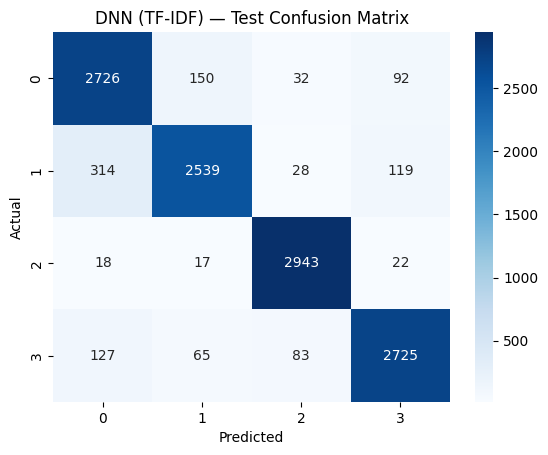

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y3_test, y_pred_dnn)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("DNN (TF-IDF) — Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

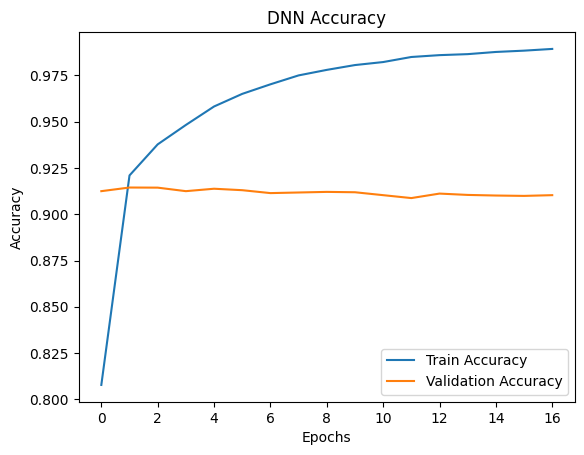

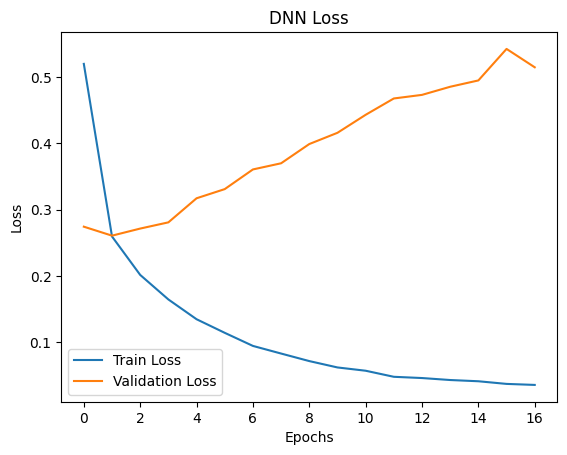

In [15]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("DNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("DNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [16]:
# ==============================
# REQUIRED LIBRARIES
# ==============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
# ==============================
# COMMON SETUP
# ==============================

# One-hot labels
y3_train_cat = tf.keras.utils.to_categorical(y3_train, num_classes=4)
y3_val_cat   = tf.keras.utils.to_categorical(y3_val, num_classes=4)

# Class weights (VERY IMPORTANT)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y3_train),
    y=y3_train
)
class_weight_dict = dict(enumerate(class_weights))

# Callbacks
es = EarlyStopping(
    monitor='val_loss',
    patience=4,
    min_delta=0.001,
    restore_best_weights=True
)

rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)
MAX_LEN = 60   

def get_sequence_matrix(tokens, model, max_len=MAX_LEN):
    vectors = []
    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])
        if len(vectors) == max_len:
            break
    while len(vectors) < max_len:
        vectors.append(np.zeros(model.vector_size))

    return np.array(vectors, dtype=np.float32)   

X3_train_seq = np.array([get_sequence_matrix(x, Skip) for x in X3_train_tokens], dtype=np.float32)
X3_val_seq   = np.array([get_sequence_matrix(x, Skip) for x in X3_val_tokens],   dtype=np.float32)
X3_test_seq  = np.array([get_sequence_matrix(x, Skip) for x in X3_test_tokens],  dtype=np.float32)
import tensorflow as tf

y3_train_cat = tf.keras.utils.to_categorical(y3_train, num_classes=4)
y3_val_cat   = tf.keras.utils.to_categorical(y3_val,   num_classes=4)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y3_train),
    y=y3_train
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)


{0: np.float64(0.835680236699359), 1: np.float64(2.0100158144438587), 2: np.float64(1.104657058014051), 3: np.float64(0.713978091938957)}


**Simple RNN without ES**

In [17]:
# ==============================
# SimpleRNN — WITHOUT EarlyStopping
# ==============================

model_rnn_no_es = Sequential([
    SimpleRNN(128, activation='tanh', input_shape=(MAX_LEN, 100)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model_rnn_no_es.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_rnn_no_es = model_rnn_no_es.fit(
    X3_train_seq, y3_train_cat,
    epochs=50,
    batch_size=64,
    validation_data=(X3_val_seq, y3_val_cat),
    class_weight=class_weight_dict,
    verbose=1
)

# Evaluation
y_pred = np.argmax(model_rnn_no_es.predict(X3_val_seq), axis=1)

print("===== SimpleRNN (NO EarlyStopping) =====")
print("Accuracy:", accuracy_score(y3_val, y_pred))
print("F1-score:", f1_score(y3_val, y_pred, average='macro'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.2424 - loss: 1.4917 - val_accuracy: 0.3597 - val_loss: 1.3778
Epoch 2/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2464 - loss: 1.3806 - val_accuracy: 0.2372 - val_loss: 1.6093
Epoch 3/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2857 - loss: 1.3731 - val_accuracy: 0.2296 - val_loss: 1.8668
Epoch 4/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2453 - loss: 1.3744 - val_accuracy: 0.2337 - val_loss: 1.8511
Epoch 5/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2565 - loss: 1.3771 - val_accuracy: 0.2285 - val_loss: 7.4840
Epoch 6/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2396 - loss: 1.3759 - val_accuracy: 0.1289 - val_loss: 2.9013
Epoch 7/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2490 - loss: 1.3767 - val_accuracy: 0.3011 - val_loss: 4.8114
Epoch 8/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2508 - loss: 1.3754 - val_accuracy: 

**SimpleRNN — WITH EarlyStopping**

In [18]:
# ==============================
# SimpleRNN — WITH EarlyStopping
# ==============================

model_rnn_es = Sequential([
    SimpleRNN(128, activation='tanh', input_shape=(MAX_LEN, 100)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model_rnn_es.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_rnn_es = model_rnn_es.fit(
    X3_train_seq, y3_train_cat,
    epochs=50,
    batch_size=64,
    validation_data=(X3_val_seq, y3_val_cat),
    class_weight=class_weight_dict,
    callbacks=[es, rlr],
    verbose=1
)

# Evaluation
y_pred = np.argmax(model_rnn_es.predict(X3_val_seq), axis=1)

print("===== SimpleRNN (WITH EarlyStopping) =====")
print("Accuracy:", accuracy_score(y3_val, y_pred))
print("F1-score:", f1_score(y3_val, y_pred, average='macro'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.2780 - loss: 1.4680 - val_accuracy: 0.3591 - val_loss: 1.6229 - learning_rate: 0.0010
Epoch 2/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2498 - loss: 1.3817 - val_accuracy: 0.3505 - val_loss: 10.3763 - learning_rate: 0.0010
Epoch 3/50
948/954 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2794 - loss: 1.3846
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
954/954 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2793 - loss: 1.3845 - val_accuracy: 0.2992 - val_loss: 19.2766 - learning_rate: 0.0010
Epoch 4/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2620 - loss: 1.3805 - val_accuracy: 0.2430 - val_loss: 1.5005 - learning_rate: 5.0000e-04
Epoch 5/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2594 - loss: 1.3597 - val_accuracy: 0.3513 - val_loss: 3.5532 - learning_rate: 5.0000e-04
Epoch 6/50
952/954 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2479 - loss

477/477 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
477/477 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


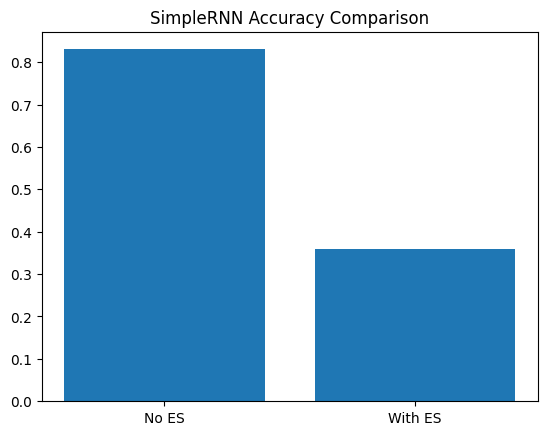

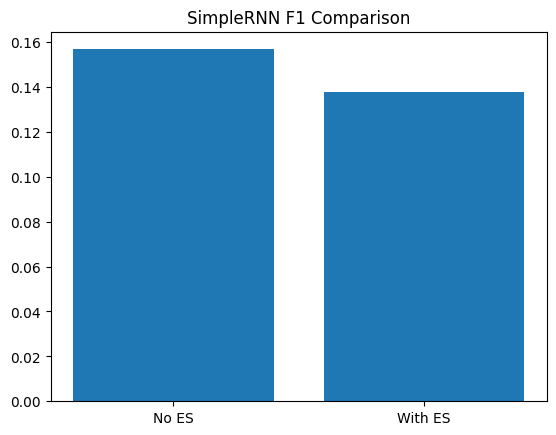

In [19]:
# Accuracy comparison
acc_no_es = max(history_rnn_no_es.history['val_accuracy'])
acc_es    = max(history_rnn_es.history['val_accuracy'])

f1_no_es = f1_score(y3_val, np.argmax(model_rnn_no_es.predict(X3_val_seq), axis=1), average='macro')
f1_es    = f1_score(y3_val, np.argmax(model_rnn_es.predict(X3_val_seq), axis=1), average='macro')

plt.figure()
plt.bar(["No ES", "With ES"], [acc_no_es, acc_es])
plt.title("SimpleRNN Accuracy Comparison")
plt.show()

plt.figure()
plt.bar(["No ES", "With ES"], [f1_no_es, f1_es])
plt.title("SimpleRNN F1 Comparison")
plt.show()

In [20]:
# ==============================
# SIMPLE RNN — TEST EVALUATION (FIXED)
# ==============================

import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

y3_test = le.transform(test['label'])

# ==============================
# SimpleRNN — NO EarlyStopping (TEST)
# ==============================

y_pred_rnn_no_es_test = np.argmax(
    model_rnn_no_es.predict(X3_test_seq),
    axis=1
)

print("===== SimpleRNN (NO EarlyStopping) — TEST =====")
print("Accuracy:", accuracy_score(y3_test, y_pred_rnn_no_es_test))
print("F1-score:", f1_score(y3_test, y_pred_rnn_no_es_test, average='macro'))

print("\nConfusion Matrix:\n", confusion_matrix(y3_test, y_pred_rnn_no_es_test))
print("\nClassification Report:\n", classification_report(y3_test, y_pred_rnn_no_es_test))


# ==============================
# SimpleRNN — WITH EarlyStopping (TEST)
# ==============================

y_pred_rnn_es_test = np.argmax(
    model_rnn_es.predict(X3_test_seq),
    axis=1
)

print("\n===== SimpleRNN (WITH EarlyStopping) — TEST =====")
print("Accuracy:", accuracy_score(y3_test, y_pred_rnn_es_test))
print("F1-score:", f1_score(y3_test, y_pred_rnn_es_test, average='macro'))

print("\nConfusion Matrix:\n", confusion_matrix(y3_test, y_pred_rnn_es_test))
print("\nClassification Report:\n", classification_report(y3_test, y_pred_rnn_es_test))

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
===== SimpleRNN (NO EarlyStopping) — TEST =====
Accuracy: 0.2589166666666667
F1-score: 0.12061358777473621

Confusion Matrix:
 [[  66    6    0 2928]
 [  36   51    0 2913]
 [   1    1    6 2992]
 [  14    2    0 2984]]

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.02      0.04      3000
           1       0.85      0.02      0.03      3000
           2       1.00      0.00      0.00      3000
           3       0.25      0.99      0.40      3000

    accuracy                           0.26     12000
   macro avg       0.67      0.26      0.12     12000
weighted avg       0.67      0.26      0.12     12000

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

===== SimpleRNN (WITH EarlyStopping) — TEST =====
Accuracy: 0.26408333333333334
F1-score: 0.13457978215295832

Confusion Matrix:
 [[  36   85 2864   15]
 [  16  127 2839   18]
 [   0   25 2958   17]
 [  14   38 2900   48]]

Classificatio

**LSTM without es**

In [21]:
model_lstm_no_es = Sequential([
    LSTM(128, input_shape=(MAX_LEN, 100)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model_lstm_no_es.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_lstm_no_es = model_lstm_no_es.fit(
    X3_train_seq, y3_train_cat,
    epochs=50,
    batch_size=64,
    validation_data=(X3_val_seq, y3_val_cat),
    class_weight=class_weight_dict,
    verbose=1
)

# Evaluation
y_pred_lstm_no_es = np.argmax(model_lstm_no_es.predict(X3_val_seq), axis=1)

print("===== LSTM (NO EarlyStopping) =====")
print("Accuracy:", accuracy_score(y3_val, y_pred_lstm_no_es))
print("F1-score:", f1_score(y3_val, y_pred_lstm_no_es, average='macro'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.7735 - loss: 0.6059 - val_accuracy: 0.8888 - val_loss: 0.3705
Epoch 2/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8808 - loss: 0.3633 - val_accuracy: 0.8996 - val_loss: 0.2979
Epoch 3/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8904 - loss: 0.3227 - val_accuracy: 0.9031 - val_loss: 0.3054
Epoch 4/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8930 - loss: 0.3062 - val_accuracy: 0.9007 - val_loss: 0.2896
Epoch 5/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8976 - loss: 0.2852 - val_accuracy: 0.9024 - val_loss: 0.2815
Epoch 6/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9041 - loss: 0.2670 - val_accuracy: 0.9118 - val_loss: 0.2603
Epoch 7/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9098 - loss: 0.2491 - val_accuracy: 0.9144 - val_loss: 0.2539
Epoch 8/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9098 - loss: 0.2459 - val_acc

**LSTM with es**

In [22]:
model_lstm_es = Sequential([
    LSTM(128, input_shape=(MAX_LEN, 100)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model_lstm_es.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_lstm_es = model_lstm_es.fit(
    X3_train_seq, y3_train_cat,
    epochs=50,
    batch_size=64,
    validation_data=(X3_val_seq, y3_val_cat),
    class_weight=class_weight_dict,
    callbacks=[es, rlr],
    verbose=1
)

# Evaluation
y_pred_lstm_es = np.argmax(model_lstm_es.predict(X3_val_seq), axis=1)

print("===== LSTM (WITH EarlyStopping) =====")
print("Accuracy:", accuracy_score(y3_val, y_pred_lstm_es))
print("F1-score:", f1_score(y3_val, y_pred_lstm_es, average='macro'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.7895 - loss: 0.5878 - val_accuracy: 0.8798 - val_loss: 0.3877 - learning_rate: 0.0010
Epoch 2/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8782 - loss: 0.3610 - val_accuracy: 0.8592 - val_loss: 0.3810 - learning_rate: 0.0010
Epoch 3/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8882 - loss: 0.3239 - val_accuracy: 0.8857 - val_loss: 0.3378 - learning_rate: 0.0010
Epoch 4/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8957 - loss: 0.2982 - val_accuracy: 0.9033 - val_loss: 0.2892 - learning_rate: 0.0010
Epoch 5/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9020 - loss: 0.2839 - val_accuracy: 0.9101 - val_loss: 0.2682 - learning_rate: 0.0010
Epoch 6/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9090 - loss: 0.2568 - val_accuracy: 0.9115 - val_loss: 0.2546 - learning_rate: 0.0010
Epoch 7/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9104 - loss: 0

In [23]:
y_pred_lstm_no_es_test = np.argmax(
    model_lstm_no_es.predict(X3_test_seq),
    axis=1
)

print("===== LSTM (NO EarlyStopping) — TEST =====")
print("Predictions:", y_pred_lstm_no_es_test)
y_pred_lstm_es_test = np.argmax(
    model_lstm_es.predict(X3_test_seq),
    axis=1
)

print("===== LSTM (WITH EarlyStopping) — TEST =====")
print("Predictions:", y_pred_lstm_es_test)
print("===== LSTM TEST METRICS =====")

print("Accuracy:", accuracy_score(y3_test, y_pred_lstm_es_test))
print("F1-score:", f1_score(y3_test, y_pred_lstm_es_test, average='macro'))

print("\nConfusion Matrix:\n", confusion_matrix(y3_test, y_pred_lstm_es_test))
print("\nClassification Report:\n", classification_report(y3_test, y_pred_lstm_es_test))

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
===== LSTM (NO EarlyStopping) — TEST =====
Predictions: [1 0 3 ... 3 3 1]
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
===== LSTM (WITH EarlyStopping) — TEST =====
Predictions: [1 1 3 ... 3 3 1]
===== LSTM TEST METRICS =====
Accuracy: 0.9239166666666667
F1-score: 0.9238086095484369

Confusion Matrix:
 [[2658  239   27   76]
 [ 170 2748   19   63]
 [  15   10 2958   17]
 [ 120   91   66 2723]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.89      0.89      3000
           1       0.89      0.92      0.90      3000
           2       0.96      0.99      0.97      3000
           3       0.95      0.91      0.93      3000

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000



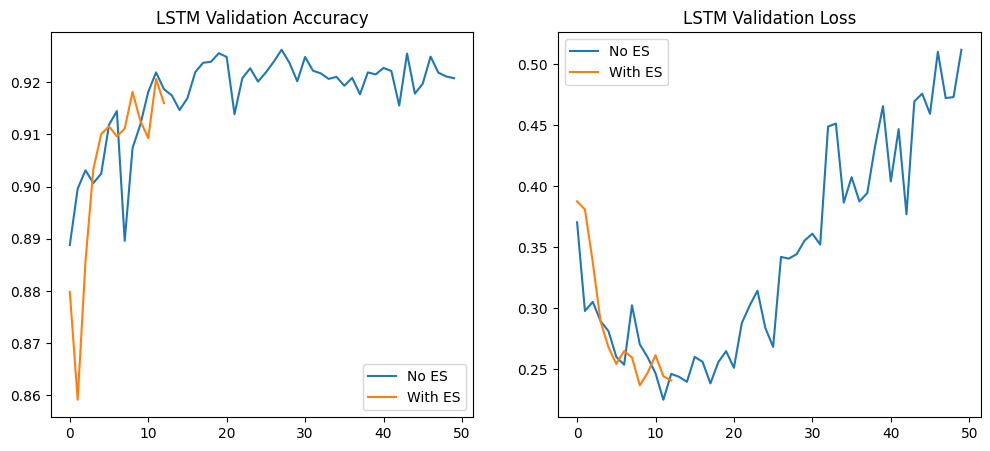

In [24]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_lstm_no_es.history['val_accuracy'], label='No ES')
plt.plot(history_lstm_es.history['val_accuracy'], label='With ES')
plt.title("LSTM Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_lstm_no_es.history['val_loss'], label='No ES')
plt.plot(history_lstm_es.history['val_loss'], label='With ES')
plt.title("LSTM Validation Loss")
plt.legend()

plt.show()

**GRU without es**

In [25]:
model_gru_no_es = Sequential([
    GRU(128, input_shape=(MAX_LEN, 100)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model_gru_no_es.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_gru_no_es = model_gru_no_es.fit(
    X3_train_seq, y3_train_cat,
    epochs=50,
    batch_size=64,
    validation_data=(X3_val_seq, y3_val_cat),
    class_weight=class_weight_dict,
    verbose=1
)

# Evaluation
y_pred_gru_no_es = np.argmax(model_gru_no_es.predict(X3_val_seq), axis=1)

print("===== GRU (NO EarlyStopping) =====")
print("Accuracy:", accuracy_score(y3_val, y_pred_gru_no_es))
print("F1-score:", f1_score(y3_val, y_pred_gru_no_es, average='macro'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.5633 - loss: 0.9255 - val_accuracy: 0.8840 - val_loss: 0.3238
Epoch 2/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8848 - loss: 0.3298 - val_accuracy: 0.8403 - val_loss: 0.4314
Epoch 3/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8918 - loss: 0.2986 - val_accuracy: 0.8995 - val_loss: 0.2861
Epoch 4/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9015 - loss: 0.2734 - val_accuracy: 0.9040 - val_loss: 0.2737
Epoch 5/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9040 - loss: 0.2553 - val_accuracy: 0.9018 - val_loss: 0.2775
Epoch 6/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9098 - loss: 0.2477 - val_accuracy: 0.9184 - val_loss: 0.2386
Epoch 7/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9131 - loss: 0.2354 - val_accuracy: 0.9098 - val_loss: 0.2643
Epoch 8/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9191 - loss: 0.2227 - val_acc

**GRU with es**

In [26]:
model_gru_es = Sequential([
    GRU(128, input_shape=(MAX_LEN, 100)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model_gru_es.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_gru_es = model_gru_es.fit(
    X3_train_seq, y3_train_cat,
    epochs=50,
    batch_size=64,
    validation_data=(X3_val_seq, y3_val_cat),
    class_weight=class_weight_dict,
    callbacks=[es, rlr],
    verbose=1
)

# Evaluation
y_pred_gru_es = np.argmax(model_gru_es.predict(X3_val_seq), axis=1)

print("===== GRU (WITH EarlyStopping) =====")
print("Accuracy:", accuracy_score(y3_val, y_pred_gru_es))
print("F1-score:", f1_score(y3_val, y_pred_gru_es, average='macro'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.5671 - loss: 0.9537 - val_accuracy: 0.9000 - val_loss: 0.2975 - learning_rate: 0.0010
Epoch 2/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8877 - loss: 0.3259 - val_accuracy: 0.8870 - val_loss: 0.3323 - learning_rate: 0.0010
Epoch 3/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8958 - loss: 0.2905
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8958 - loss: 0.2905 - val_accuracy: 0.8932 - val_loss: 0.3113 - learning_rate: 0.0010
Epoch 4/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8994 - loss: 0.2678 - val_accuracy: 0.9091 - val_loss: 0.2551 - learning_rate: 5.0000e-04
Epoch 5/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9057 - loss: 0.2570 - val_accuracy: 0.8966 - val_loss: 0.3028 - learning_rate: 5.0000e-04
Epoch 6/50
954/954 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9077 - lo

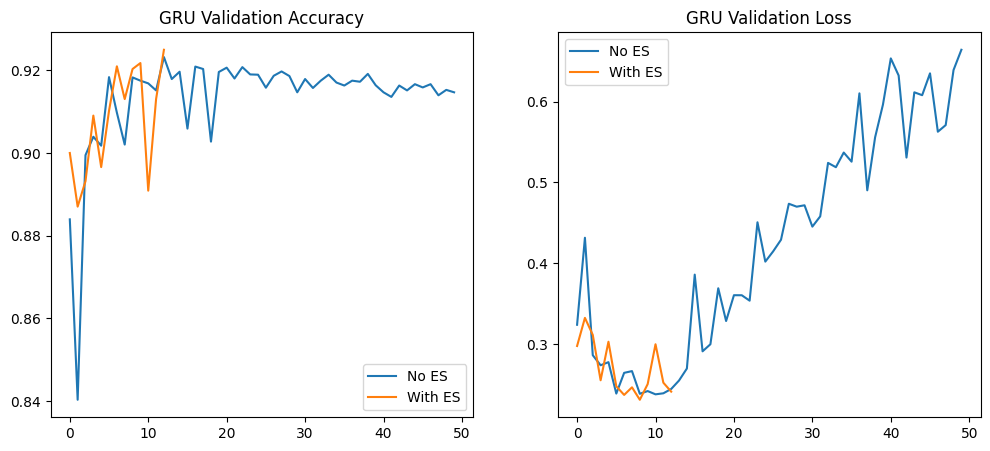

In [27]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_gru_no_es.history['val_accuracy'], label='No ES')
plt.plot(history_gru_es.history['val_accuracy'], label='With ES')
plt.title("GRU Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_gru_no_es.history['val_loss'], label='No ES')
plt.plot(history_gru_es.history['val_loss'], label='With ES')
plt.title("GRU Validation Loss")
plt.legend()

plt.show()

In [28]:
# ==============================
# GRU — TEST EVALUATION (FIXED)
# ==============================

import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

y3_test = le.transform(test['label'])

# ==============================
# GRU — NO EarlyStopping (TEST)
# ==============================

y_pred_gru_no_es_test = np.argmax(
    model_gru_no_es.predict(X3_test_seq),
    axis=1
)

print("===== GRU (NO EarlyStopping) — TEST =====")
print("Accuracy:", accuracy_score(y3_test, y_pred_gru_no_es_test))
print("F1-score:", f1_score(y3_test, y_pred_gru_no_es_test, average='macro'))

print("\nConfusion Matrix:\n", confusion_matrix(y3_test, y_pred_gru_no_es_test))
print("\nClassification Report:\n", classification_report(y3_test, y_pred_gru_no_es_test))


# ==============================
# GRU — WITH EarlyStopping (TEST)
# ==============================

y_pred_gru_es_test = np.argmax(
    model_gru_es.predict(X3_test_seq),
    axis=1
)

print("\n===== GRU (WITH EarlyStopping) — TEST =====")
print("Accuracy:", accuracy_score(y3_test, y_pred_gru_es_test))
print("F1-score:", f1_score(y3_test, y_pred_gru_es_test, average='macro'))

print("\nConfusion Matrix:\n", confusion_matrix(y3_test, y_pred_gru_es_test))
print("\nClassification Report:\n", classification_report(y3_test, y_pred_gru_es_test))

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
===== GRU (NO EarlyStopping) — TEST =====
Accuracy: 0.9025
F1-score: 0.9020971527644263

Confusion Matrix:
 [[2733  138   26  103]
 [ 404 2416   27  153]
 [  29   12 2922   37]
 [ 118   67   56 2759]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      3000
           1       0.92      0.81      0.86      3000
           2       0.96      0.97      0.97      3000
           3       0.90      0.92      0.91      3000

    accuracy                           0.90     12000
   macro avg       0.90      0.90      0.90     12000
weighted avg       0.90      0.90      0.90     12000

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

===== GRU (WITH EarlyStopping) — TEST =====
Accuracy: 0.91625
F1-score: 0.9160233121659115

Confusion Matrix:
 [[2655  184   22  139]
 [ 243 2600   16  141]
 [  24    6 2934   36]
 [  79   64   51 2806]]

Classification Report:
               precision    

**BiLSTM with no es**

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
import tensorflow as tf
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

tf.keras.backend.clear_session()

model_bilstm_no_es = Sequential([
    Input(shape=(MAX_LEN, 100)),
    Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.1)),

    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(16, activation='relu'),   # 4th hidden layer
    Dense(4, activation='softmax')
])

model_bilstm_no_es.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_bilstm_no_es.summary()

history_bilstm_no_es = model_bilstm_no_es.fit(
    X3_train_seq, y3_train_cat,
    epochs=25,
    batch_size=128,
    validation_data=(X3_val_seq, y3_val_cat),
    class_weight=class_weight_dict,
    verbose=1
)

print("\n===== BiLSTM (NO ES) =====")
print("Training Accuracy:", history_bilstm_no_es.history['accuracy'][-1])
print("Validation Accuracy:", history_bilstm_no_es.history['val_accuracy'][-1])

y_pred_no_es = np.argmax(model_bilstm_no_es.predict(X3_test_seq), axis=1)

print("\n===== BiLSTM (NO ES) — TEST =====")
print("Accuracy:", accuracy_score(y3_test, y_pred_no_es))
print("F1-score:", f1_score(y3_test, y_pred_no_es, average='macro'))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279,348 (1.07 MB)

 Trainable params: 278,836 (1.06 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 108s 212ms/step - accuracy: 0.6231 - loss: 0.8200 - val_accuracy: 0.8924 - val_loss: 0.3342
Epoch 2/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 100s 209ms/step - accuracy: 0.8616 - loss: 0.4213 - val_accuracy: 0.8886 - val_loss: 0.3242
Epoch 3/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 100s 210ms/step - accuracy: 0.8690 - loss: 0.3914 - val_accuracy: 0.8914 - val_loss: 0.3133
Epoch 4/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 100s 210ms/step - accuracy: 0.8728 - loss: 0.3703 - val_accuracy: 0.8897 - val_loss: 0.3135
Epoch 5/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 100s 209ms/step - accuracy: 0.8806 - loss: 0.3506 - val_accuracy: 0.9006 - val_loss: 0.2923
Epoch 6/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 100s 210ms/step - accuracy: 0.8819 - loss: 0.3421 - val_accuracy: 0.8923 - val_loss: 0.3009
Epoch 7/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 101s 211ms/step - accuracy: 0.8870 - loss: 0.3160 - val_accuracy: 0.9038 - val_loss: 0.2890
Epoch 8/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 101s 211ms/step - accuracy: 0.8908 -

**BILSTM with es**

In [30]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.keras.backend.clear_session()

model_bilstm_es = Sequential([
    Input(shape=(MAX_LEN, 100)),
    Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.1)),

    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(16, activation='relu'),   
    Dense(4, activation='softmax')
])

model_bilstm_es.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_bilstm_es.summary()

es = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True
)

rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

history_bilstm_es = model_bilstm_es.fit(
    X3_train_seq, y3_train_cat,
    epochs=25,
    batch_size=128,
    validation_data=(X3_val_seq, y3_val_cat),
    class_weight=class_weight_dict,
    callbacks=[es, rlr],
    verbose=1
)

print("\n===== BiLSTM (WITH ES) =====")
print("Training Accuracy:", history_bilstm_es.history['accuracy'][-1])
print("Validation Accuracy:", history_bilstm_es.history['val_accuracy'][-1])

y_pred_es = np.argmax(model_bilstm_es.predict(X3_test_seq), axis=1)

print("\n===== BiLSTM (WITH ES) — TEST =====")
print("Accuracy:", accuracy_score(y3_test, y_pred_es))
print("F1-score:", f1_score(y3_test, y_pred_es, average='macro'))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279,348 (1.07 MB)

 Trainable params: 278,836 (1.06 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 105s 207ms/step - accuracy: 0.6990 - loss: 0.8196 - val_accuracy: 0.8864 - val_loss: 0.3478 - learning_rate: 5.0000e-04
Epoch 2/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 96s 201ms/step - accuracy: 0.8610 - loss: 0.4199 - val_accuracy: 0.8773 - val_loss: 0.3453 - learning_rate: 5.0000e-04
Epoch 3/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 95s 200ms/step - accuracy: 0.8715 - loss: 0.3838 - val_accuracy: 0.8810 - val_loss: 0.3403 - learning_rate: 5.0000e-04
Epoch 4/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 95s 200ms/step - accuracy: 0.8800 - loss: 0.3543 - val_accuracy: 0.8854 - val_loss: 0.3141 - learning_rate: 5.0000e-04
Epoch 5/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 96s 201ms/step - accuracy: 0.8818 - loss: 0.3482 - val_accuracy: 0.8705 - val_loss: 0.3344 - learning_rate: 5.0000e-04
Epoch 6/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 96s 201ms/step - accuracy: 0.8807 - loss: 0.3347 - val_accuracy: 0.8962 - val_loss: 0.2874 - learning_rate: 5.0000e-04
Epoch 7/25
477/477 ━━━━━━━━━━━━━━━━━━━━ 96s 2

In [31]:
from sklearn.metrics import confusion_matrix, classification_report

print("\n===== BiLSTM (NO ES) — CONFUSION MATRIX =====")
cm_no_es = confusion_matrix(y3_test, y_pred_no_es)
print(cm_no_es)

print("\n===== BiLSTM (NO ES) — CLASSIFICATION REPORT =====")
print(classification_report(y3_test, y_pred_no_es))
print("\n===== BiLSTM (WITH ES) — CONFUSION MATRIX =====")
cm_es = confusion_matrix(y3_test, y_pred_es)
print(cm_es)

print("\n===== BiLSTM (WITH ES) — CLASSIFICATION REPORT =====")
print(classification_report(y3_test, y_pred_es))


===== BiLSTM (NO ES) — CONFUSION MATRIX =====
[[2688  211   29   72]
 [ 227 2675   18   80]
 [  18    5 2960   17]
 [ 124   68   62 2746]]

===== BiLSTM (NO ES) — CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.88      0.90      0.89      3000
           1       0.90      0.89      0.90      3000
           2       0.96      0.99      0.98      3000
           3       0.94      0.92      0.93      3000

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000


===== BiLSTM (WITH ES) — CONFUSION MATRIX =====
[[2678  219   34   69]
 [ 204 2723   25   48]
 [  16    7 2959   18]
 [ 113  101   71 2715]]

===== BiLSTM (WITH ES) — CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      3000
           1       0.89      0.91      0.90      3000
           2  

375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step

===== TEST ACCURACY COMPARISON =====
BiLSTM No ES Accuracy: 0.9224166666666667
BiLSTM With ES Accuracy: 0.9229166666666667


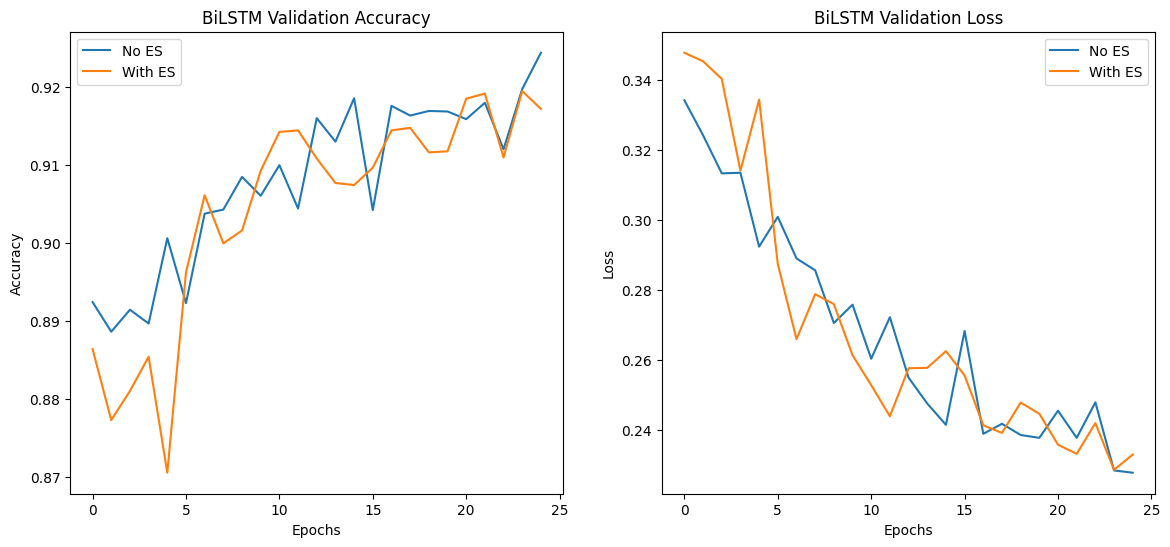

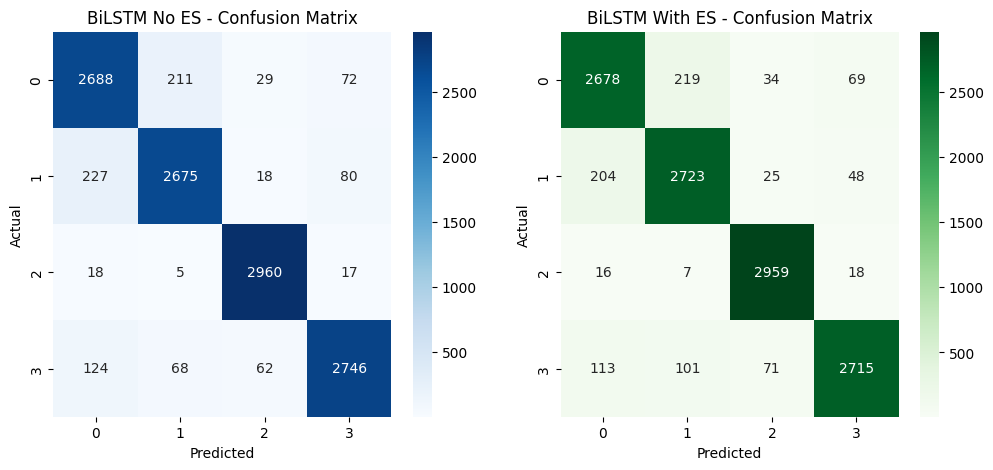

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# -------------------------
# Predictions (TEST SET)
# -------------------------
y_pred_no_es = np.argmax(model_bilstm_no_es.predict(X3_test_seq), axis=1)
y_pred_es = np.argmax(model_bilstm_es.predict(X3_test_seq), axis=1)

# -------------------------
# TEST ACCURACY
# -------------------------
acc_no_es = accuracy_score(y3_test, y_pred_no_es)
acc_es = accuracy_score(y3_test, y_pred_es)

print("\n===== TEST ACCURACY COMPARISON =====")
print("BiLSTM No ES Accuracy:", acc_no_es)
print("BiLSTM With ES Accuracy:", acc_es)

# -------------------------
# PLOTS
# -------------------------
plt.figure(figsize=(14,6))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history_bilstm_no_es.history['val_accuracy'], label='No ES')
plt.plot(history_bilstm_es.history['val_accuracy'], label='With ES')
plt.title("BiLSTM Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history_bilstm_no_es.history['val_loss'], label='No ES')
plt.plot(history_bilstm_es.history['val_loss'], label='With ES')
plt.title("BiLSTM Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

# -------------------------
# CONFUSION MATRIX
# -------------------------
plt.figure(figsize=(12,5))

# No ES CM
plt.subplot(1,2,1)
cm_no_es = confusion_matrix(y3_test, y_pred_no_es)
sns.heatmap(cm_no_es, annot=True, fmt='d', cmap='Blues')
plt.title("BiLSTM No ES - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# With ES CM
plt.subplot(1,2,2)
cm_es = confusion_matrix(y3_test, y_pred_es)
sns.heatmap(cm_es, annot=True, fmt='d', cmap='Greens')
plt.title("BiLSTM With ES - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**BI RNN**

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 256)            │        58,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,772 (307.70 KB)

 Trainable params: 78,260 (305.70 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/20
477/477 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6672 - loss: 0.8658 - val_accuracy: 0.8459 - val_loss: 0.4622 - learning_rate: 5.0000e-04
Epoch 2/20
477/477 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8655 - loss: 0.4203 - val_accuracy: 0.8794 - val_loss: 0.3676 - learning_rate: 5.0000e-04
Epoch 3/20
477/477 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8749 - loss: 0.3760 - val_accuracy: 0.8885 - val_loss: 0.3496 - learning_rate: 5.0000e-04
Epoch 4/20
477/477 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8780 - loss: 0.3645 - val_accuracy: 0.8739 - val_loss: 0.3598 - learning_rate: 5.0000e-04
Epoch 5/20
477/477 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8839 - loss: 0.3459 - val_accuracy: 0.8925 - val_loss: 0.3452 - learning_rate: 5.0000e-04
Epoch 6/20
477/477 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8831 - loss: 0.3434 - val_accuracy: 0.8972 - val_loss: 0.3134 - learning_rate: 5.0000e-04
Epoch 7/20
477/477 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - ac

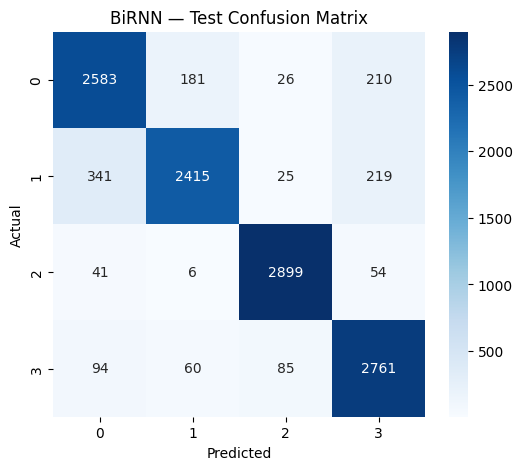

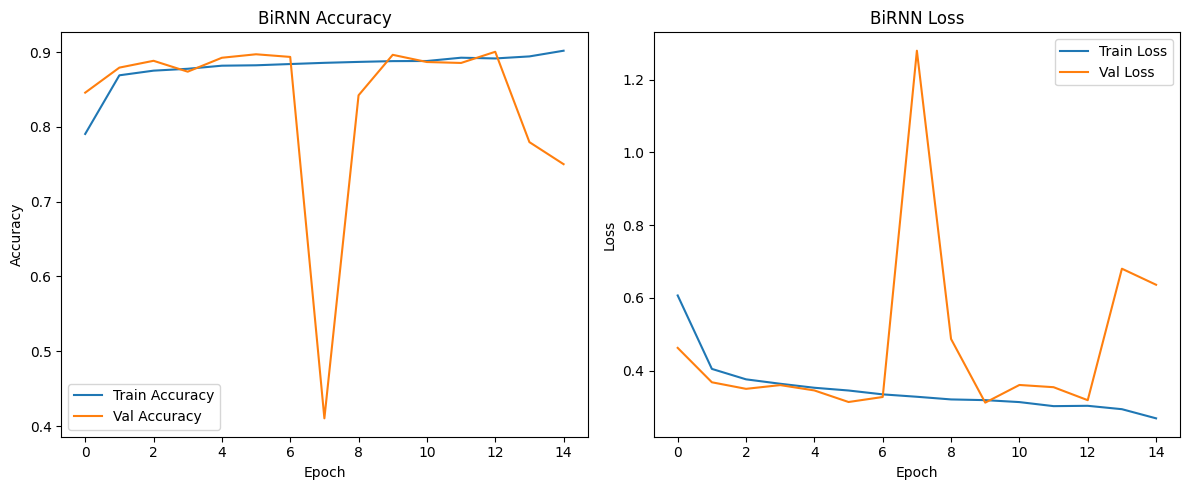

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, SimpleRNN, Dense, Dropout, BatchNormalization
import tensorflow as tf

tf.keras.backend.clear_session()

model_birnn = Sequential([
    Input(shape=(MAX_LEN, 100)),
    Bidirectional(SimpleRNN(128, activation='tanh')),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    # ✅ Added 2 more layers (ONLY change)
    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(16, activation='relu'),

    Dense(4, activation='softmax')
])

model_birnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_birnn.summary()

es = EarlyStopping(monitor='val_loss', patience=5, min_delta=0.001, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

history_birnn = model_birnn.fit(
    X3_train_seq, y3_train_cat,
    epochs=20,
    batch_size=128,
    validation_data=(X3_val_seq, y3_val_cat),
    class_weight=class_weight_dict,
    callbacks=[es, rlr],
    verbose=1
)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import numpy as np

# 🔹 Predictions
y_pred_prob = model_birnn.predict(X3_val_seq, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\n===== Bidirectional SimpleRNN =====")
print("Accuracy:", accuracy_score(y3_val, y_pred))
print("F1-score (macro):", f1_score(y3_val, y_pred, average='macro'))

print("\nClassification Report:\n")
print(classification_report(y3_val, y_pred))
# ==============================
# BiRNN (Skip-gram) — TEST SET
# ==============================

# Predict on test
y_pred_prob_test = model_birnn.predict(X3_test_seq, verbose=0)
y_pred_birnn_test = np.argmax(y_pred_prob_test, axis=1)

print("\n===== Bidirectional SimpleRNN — TEST SET =====")
print("Accuracy:", accuracy_score(y3_test, y_pred_birnn_test))
print("F1-score (macro):", f1_score(y3_test, y_pred_birnn_test, average='macro'))

print("\nClassification Report:\n")
print(classification_report(y3_test, y_pred_birnn_test))
cm_test = confusion_matrix(y3_test, y_pred_birnn_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title("BiRNN — Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_birnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_birnn.history['val_accuracy'], label='Val Accuracy')
plt.title('BiRNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_birnn.history['loss'], label='Train Loss')
plt.plot(history_birnn.history['val_loss'], label='Val Loss')
plt.title('BiRNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**BI GRU**

In [34]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.keras.backend.clear_session()

# Model
model_bigru_es = Sequential([
    Input(shape=(MAX_LEN, 100)),
    Bidirectional(GRU(128, dropout=0.2, recurrent_dropout=0.1)),

    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(4, activation='softmax')
])

model_bigru_es.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_bigru_es.summary()

# Callbacks
es = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True
)

rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

# Train
history_bigru_es = model_bigru_es.fit(
    X3_train_seq, y3_train_cat,
    epochs=30,
    batch_size=128,
    validation_data=(X3_val_seq, y3_val_cat),
    class_weight=class_weight_dict,
    callbacks=[es, rlr],
    verbose=1
)

# Print Accuracy
print("\n===== BiGRU (WITH ES) =====")
print("Final Training Accuracy:", history_bigru_es.history['accuracy'][-1])
print("Final Validation Accuracy:", history_bigru_es.history['val_accuracy'][-1])

# Test
y_pred_bigru_es_test = np.argmax(
    model_bigru_es.predict(X3_test_seq),
    axis=1
)

print("\n===== BiGRU (WITH ES) — TEST =====")
print("Accuracy:", accuracy_score(y3_test, y_pred_bigru_es_test))
print("F1-score:", f1_score(y3_test, y_pred_bigru_es_test, average='macro'))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 256)            │       176,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,028 (863.39 KB)

 Trainable params: 220,516 (861.39 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/30
477/477 ━━━━━━━━━━━━━━━━━━━━ 100s 198ms/step - accuracy: 0.6172 - loss: 0.9301 - val_accuracy: 0.8859 - val_loss: 0.3590 - learning_rate: 5.0000e-04
Epoch 2/30
477/477 ━━━━━━━━━━━━━━━━━━━━ 93s 195ms/step - accuracy: 0.8571 - loss: 0.4376 - val_accuracy: 0.8788 - val_loss: 0.3522 - learning_rate: 5.0000e-04
Epoch 3/30
477/477 ━━━━━━━━━━━━━━━━━━━━ 93s 195ms/step - accuracy: 0.8672 - loss: 0.3929 - val_accuracy: 0.8945 - val_loss: 0.3043 - learning_rate: 5.0000e-04
Epoch 4/30
477/477 ━━━━━━━━━━━━━━━━━━━━ 93s 194ms/step - accuracy: 0.8796 - loss: 0.3560 - val_accuracy: 0.9013 - val_loss: 0.2836 - learning_rate: 5.0000e-04
Epoch 5/30
477/477 ━━━━━━━━━━━━━━━━━━━━ 93s 195ms/step - accuracy: 0.8804 - loss: 0.3455 - val_accuracy: 0.8977 - val_loss: 0.2855 - learning_rate: 5.0000e-04
Epoch 6/30
477/477 ━━━━━━━━━━━━━━━━━━━━ 93s 195ms/step - accuracy: 0.8847 - loss: 0.3295 - val_accuracy: 0.8980 - val_loss: 0.2776 - learning_rate: 5.0000e-04
Epoch 7/30
477/477 ━━━━━━━━━━━━━━━━━━━━ 92s 1

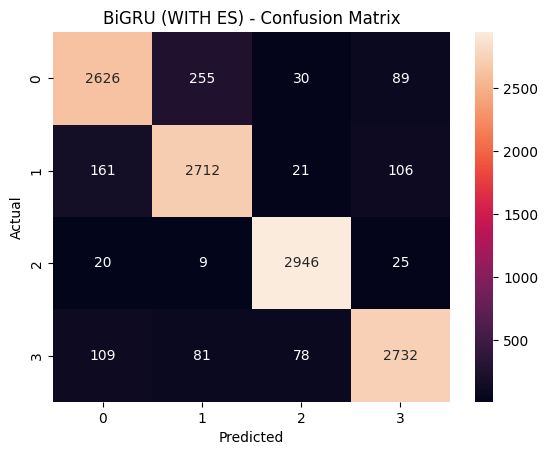


===== BiGRU (WITH ES) — CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      3000
           1       0.89      0.90      0.90      3000
           2       0.96      0.98      0.97      3000
           3       0.93      0.91      0.92      3000

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000



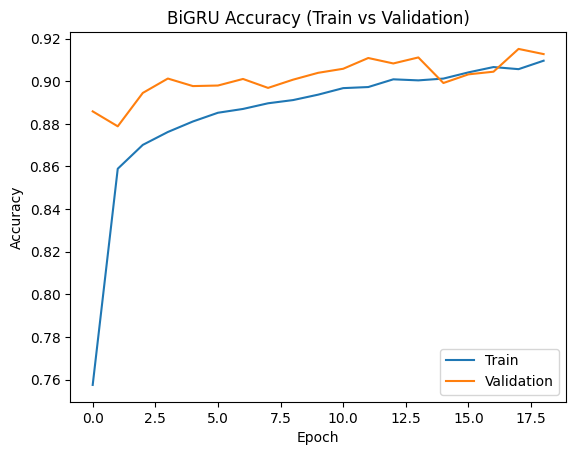

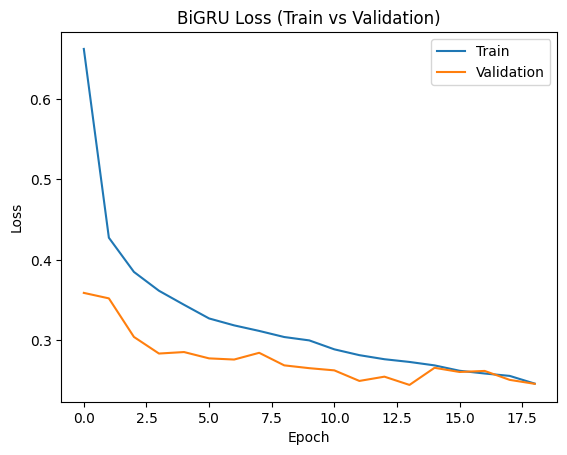

In [35]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# EVALUATION: BiGRU (WITH ES)
# ==============================

# Confusion Matrix
cm = confusion_matrix(y3_test, y_pred_bigru_es_test)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("BiGRU (WITH ES) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\n===== BiGRU (WITH ES) — CLASSIFICATION REPORT =====")
print(classification_report(y3_test, y_pred_bigru_es_test))


# ==============================
# TRAINING CURVES
# ==============================

# Accuracy Plot
plt.figure()
plt.plot(history_bigru_es.history['accuracy'])
plt.plot(history_bigru_es.history['val_accuracy'])
plt.title('BiGRU Accuracy (Train vs Validation)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss Plot
plt.figure()
plt.plot(history_bigru_es.history['loss'])
plt.plot(history_bigru_es.history['val_loss'])
plt.title('BiGRU Loss (Train vs Validation)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()